# **Fundamentos de aprendizaje por refuerzo**
## **Aprendizaje No Supervisado:** Agrupación (Clustering)
## **Algortimo:** K-Means

<img src="https://miro.medium.com/v2/resize:fit:786/format:webp/1*Nx6IyGfRAV1ly6uDGnVCxQ.gif" alt="QL_Algorithm" width="500"/>

**Clustering (Agrupación)**
- La agrupación es la tarea de dividir la población o los puntos de datos en una serie de grupos de forma que los puntos de datos de los mismos grupos sean más similares a otros puntos de datos del mismo grupo que los de otros grupos.
- El objetivo es segregar grupos con rasgos similares y asignarlos en clusters.

**K-Means Clustering**
1. Define un número objetivo K, que se refiere al número de centroides que necesita en el conjunto de datos.
2. Un centroide es la ubicación imaginaria o real que representa el centro del grupo.
3. Cada punto de datos se asigna a cada uno de los clústeres mediante la reducción de la suma de cuadrados dentro del clúster.
4. En otras palabras, el algoritmo K-means identifica un número k de centroides y, a continuación, asigna cada punto de datos al grupo más cercano, manteniendo los centroides lo más pequeños posible.
5. El "medio" en K-means se refiere al promedio de los datos, es decir, a la búsqueda del centroide.

### **Librerías**

In [ ]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

### **Datos de Ejemplo**
#### Generar datos de ejemplo

(3000, 3)


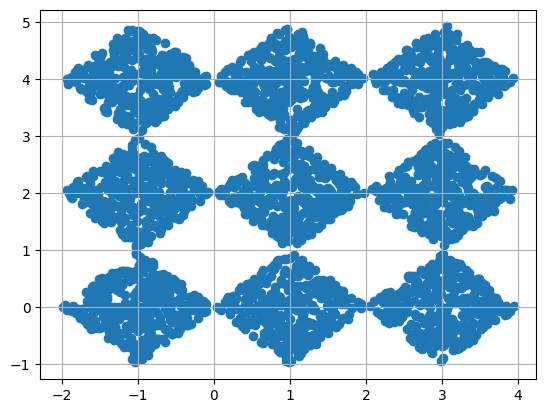

In [ ]:
data = pd.read_csv(filepath_or_buffer='https://raw.githubusercontent.com/milaan9/Clustering-Datasets/refs/heads/master/02.%20Synthetic/diamond9.csv')
print(np.shape(data))
data.head(3000)
X = data[['x','y']]
X = X.values
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
plt.show()

### **Algoritmo K-Means**



In [ ]:
from joblib import numpy_pickle_utils
def K_means(X, K, num_iterations):

  #obtiene centroides
  centroids = X[np.random.choice(range(len(X)), K, replace=False)]
  count = 0

  while count < num_iterations:
    distances = np.sqrt((X - centroids[:,np.newaxis])**2).sum(axis=2)
    labels = np.argmin(distances, axis=0)
    new_centroids = np.zeros((K, 2))

    for k in range(K):
      cluster_points = X[labels == k]
      centroid = np.mean(cluster_points, axis=0)
      new_centroids[k, :] = centroid
    if np.all(centroids == new_centroids):
      break
    centroids = new_centroids
    count += 1
  return labels, centroids

np.random.seed(32)
K = 9
num_iterations = 10000
labels, centroids = K_means(X, K, num_iterations)



#### **Gráfica de los grupos**

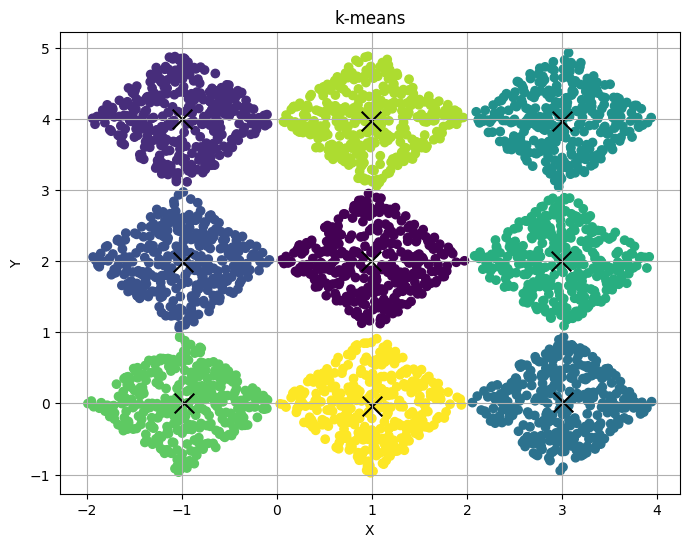

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], marker='x', color='black', s=200)
plt.title("k-means")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()

#### **K-means: grupos divididos por lineas (Librería de Sklearn)**

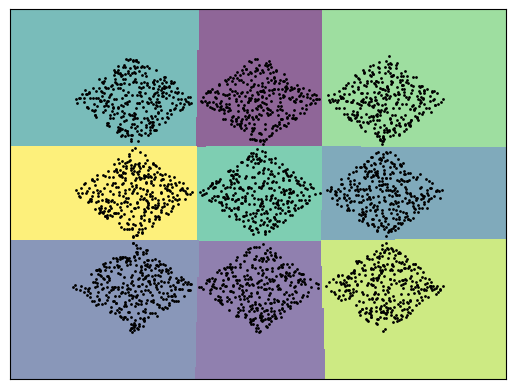

In [ ]:
# Step size of the mesh. Decrease to increase the quality of the VQ.
from sklearn.cluster import KMeans
np.random.seed(32)
kmeans = KMeans(n_clusters=K)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)
h = 0.02     # point in the mesh [x_min, x_max]x[y_min, y_max].
# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(Z, interpolation='nearest',
       extent=(xx.min(), xx.max(), yy.min(), yy.max()),
       aspect='auto', origin='lower', alpha = 0.6)

plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2, alpha=1)
# Plot the centroids as a white X
plt.scatter(centroids[:, 0], centroids[:, 1],
        marker='x', s=169, linewidths=3,
        color='w', zorder=10, alpha=1)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()

### **Evaluación del algoritmo**

**Inercia (Within-Cluster Sum of Squares, WCSS):**
- Calcula la suma de las distancias cuadradas de cada punto de datos dentro de su clúster al centroide de ese clúster.
- Valores más bajos de inercia indican una mejor agrupación, ya que significa que los puntos están más cerca de sus centroides.

In [ ]:
def inertia(X, centroids, labels):
    wcss = 0
    for i in range(len(centroids)):
        cluster_points = X[labels == i]
        wcss += np.sum((cluster_points - centroids[i])**2)
    return wcss
inercia = inertia(X, centroids, labels)
print(f"WCSS: {inercia:.4f}")

WCSS: nan


**Indice de Silueta (Silhouette Score):**
- Calcula cuán similar es un punto a su propio clúster en comparación con otros clústeres.
- Varía entre -1 y 1, donde un valor alto indica que el punto está bien clasificado en su propio clúster y mal clasificado en los clústeres vecinos.

In [ ]:
import numpy as np
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))
def silhouette_score(X, labels):
    n = len(X)
    silhouette_scores = np.zeros(n)
    for i in range(n):
        # Calcular la distancia promedio dentro del mismo clúster (a_i)
        cluster_points = X[labels == labels[i]]
        a_i = np.mean([euclidean_distance(X[i], x) for x in cluster_points])
        # Calcular la distancia promedio al clúster más cercano diferente (b_i)
        b_i = float('inf')
        for j in range(len(np.unique(labels))):
            if j != labels[i]:
                other_cluster_points = X[labels == j]
                b_ij = np.mean([euclidean_distance(X[i], x) for x in other_cluster_points])
                if b_ij < b_i:
                    b_i = b_ij
        # Calcular el índice de silueta para el punto i
        silhouette_scores[i] = (b_i - a_i) / max(a_i, b_i)
    # Calcular el puntaje de silueta promedio
    silhouette_avg = np.mean(silhouette_scores)
    return silhouette_avg
SilScore = silhouette_score(X, labels)
print("Indice de silueta:", SilScore)

/tmp/ipykernel_23899/2819382945.py:20: RuntimeWarning: invalid value encountered in scalar divide
  silhouette_scores[i] = (b_i - a_i) / max(a_i, b_i)


Indice de silueta: nan


**Coeficiente de Calinski-Harabasz (CH Score):**
- Este coeficiente mide la dispersión entre y dentro de los clústeres.
- Un valor más alto del coeficiente indica clústeres más densos y bien separados.

In [ ]:
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))
def ch_score(X, labels, centroids):
    n = len(X)
    k = len(np.unique(labels))
    overall_centroid = np.mean(X, axis=0)
    centroids_array = centroids
    numerator = np.sum([len(X[labels == label]) * euclidean_distance(centroid, overall_centroid)**2 for centroid, label in zip(centroids_array, range(k))])
    denominator = np.sum([np.sum([euclidean_distance(point, centroids_array[label])**2 for point in X[labels == label]]) for label in range(k)])
    return (numerator / (k - 1)) / (denominator / (n - k))
ch = ch_score(X, labels, centroids)
print("CH Score:", ch)

CH Score: 5855.152265816082


In [ ]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
inertia = kmeans.inertia_
silhouette = silhouette_score(X, labels)
calinski_harabasz = calinski_harabasz_score(X, labels)
davies_bouldin = davies_bouldin_score(X, labels)

# 4. Imprimir resultados
print(f"Inercia (WCSS): {inertia:.4f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Calinski-Harabasz Index: {calinski_harabasz:.4f}")
print(f"Davies-Bouldin Index: {davies_bouldin:.4f}")

Inercia (WCSS): 932.85
Silhouette Score: 0.812
Calinski-Harabasz Index: 6595.08
Davies-Bouldin Index: 0.27


# **Actividad en clase**
## **Desarrollar:**

## ELBOW Method


<img src="https://miro.medium.com/v2/resize:fit:4800/format:webp/1*zJ4EJZI6iElw2hUuWLZ9-Q.png" alt="QL_Algorithm" width="800"/>

## **1. Aplicar K-Means en el dataset:** `MallCustomers`

https://www.kaggle.com/datasets/shwetabh123/mall-customers

In [ ]:
# Cargar el conjunto de datos
data = pd.read_csv(filepath_or_buffer='https://raw.githubusercontent.com/cdavid2804/test-1/refs/heads/main/MallCustomers.xls')
print(np.shape(data))
data.head(200)


(200, 5)


,CustomerID,Gender,Age,Annual_Income_(k$),Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


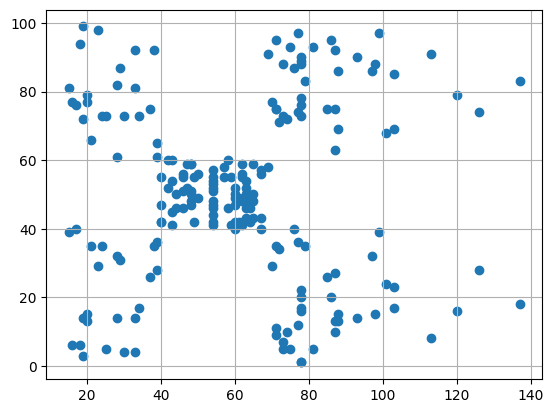

In [ ]:
X = data[['Annual_Income_(k$)','Spending_Score']]
X = X.values
plt.scatter(X[:,0],X[:,1])
plt.grid(True)
plt.show()

In [ ]:
from joblib import numpy_pickle_utils
def K_means(X, K, num_iterations):

  #obtiene centroides
  centroids = X[np.random.choice(range(len(X)), K, replace=False)]
  count = 0

  while count < num_iterations:
    distances = np.sqrt((X - centroids[:,np.newaxis])**2).sum(axis=2)
    labels = np.argmin(distances, axis=0)
    new_centroids = np.zeros((K, 2))

    for k in range(K):
      cluster_points = X[labels == k]
      centroid = np.mean(cluster_points, axis=0)
      new_centroids[k, :] = centroid
    if np.all(centroids == new_centroids):
      break
    centroids = new_centroids
    count += 1
  return labels, centroids

np.random.seed(32)
K = 5
num_iterations = 10000
labels, centroids = K_means(X, K, num_iterations)

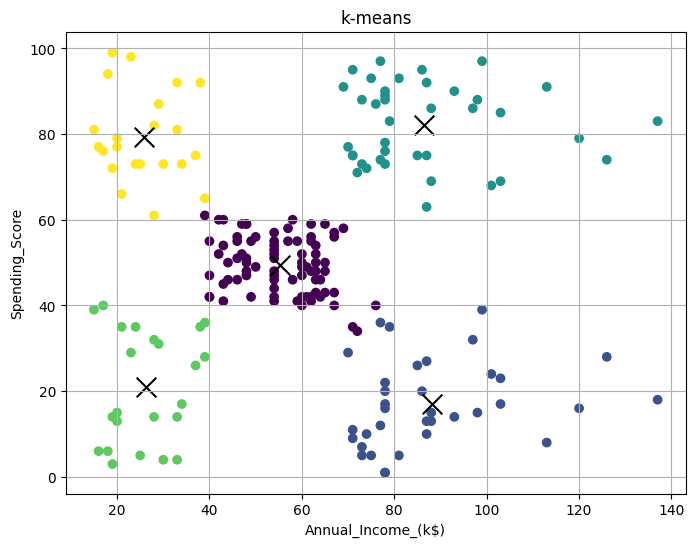

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=labels, cmap='viridis')
plt.scatter(centroids[:,0], centroids[:,1], marker='x', color='black', s=200)
plt.title("k-means")
plt.xlabel("Annual_Income_(k$)")
plt.ylabel("Spending_Score")
plt.grid()

### Graficar los datos

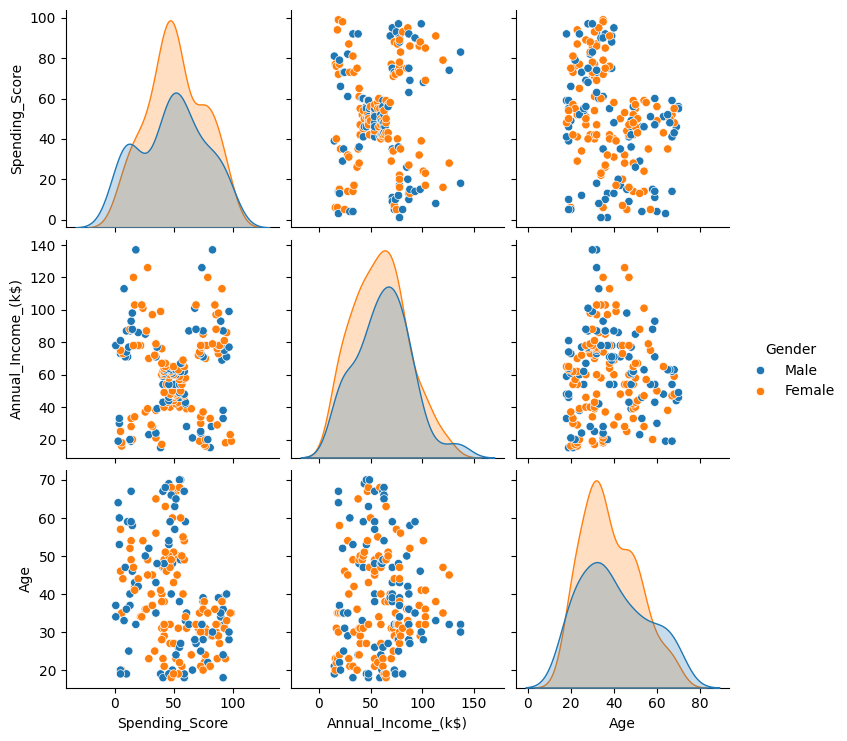

In [ ]:
sns.pairplot(data, vars = ['Spending_Score', 'Annual_Income_(k$)', 'Age'], hue = "Gender")

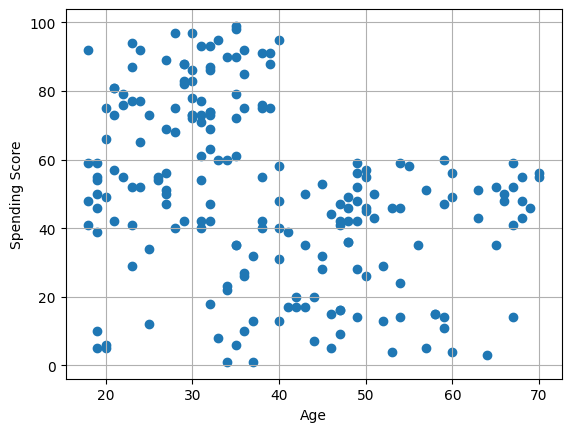

In [ ]:
X = data[['Age','Spending_Score']]
X = X.values
plt.scatter(X[:,0],X[:,1])
plt.xlabel("Age")
plt.ylabel("Spending Score")
plt.grid()

## **2. Aplicar el algortimo K-means al dataset:** `medical_insurance`:

https://www.kaggle.com/datasets/teertha/ushealthinsurancedataset

In [ ]:
# Cargar el conjunto de datos
data = pd.read_csv(filepath_or_buffer='https://raw.githubusercontent.com/cdavid2804/test-1/refs/heads/main/medical_insurance.xls')
print(np.shape(data))
data.head(2772)

(2772, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


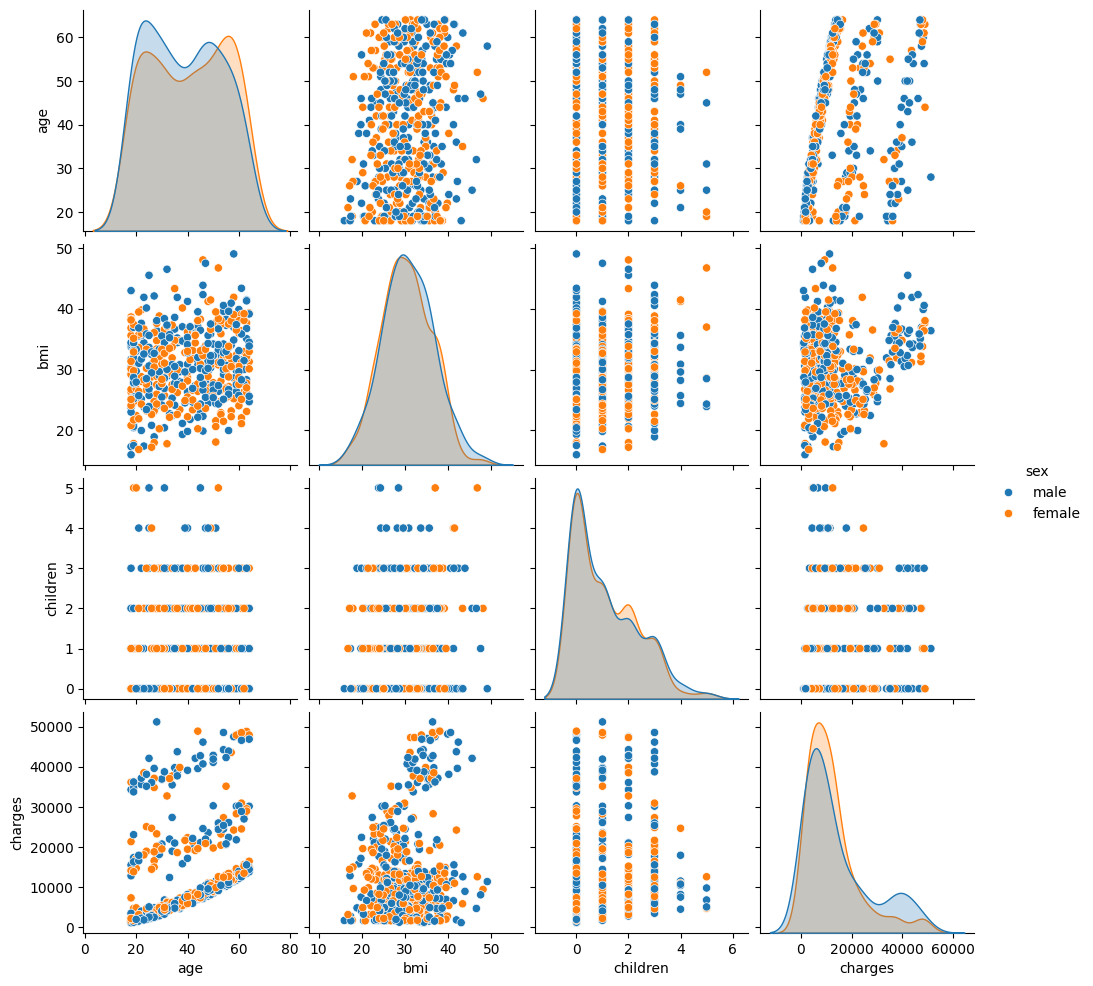

In [ ]:
sns.pairplot(data[1:500], vars = ['age', 'bmi', 'children', 'charges'], hue = 'sex')